# 1.Category Contribution and Reviews Distribution

/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_50553/1277736165.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


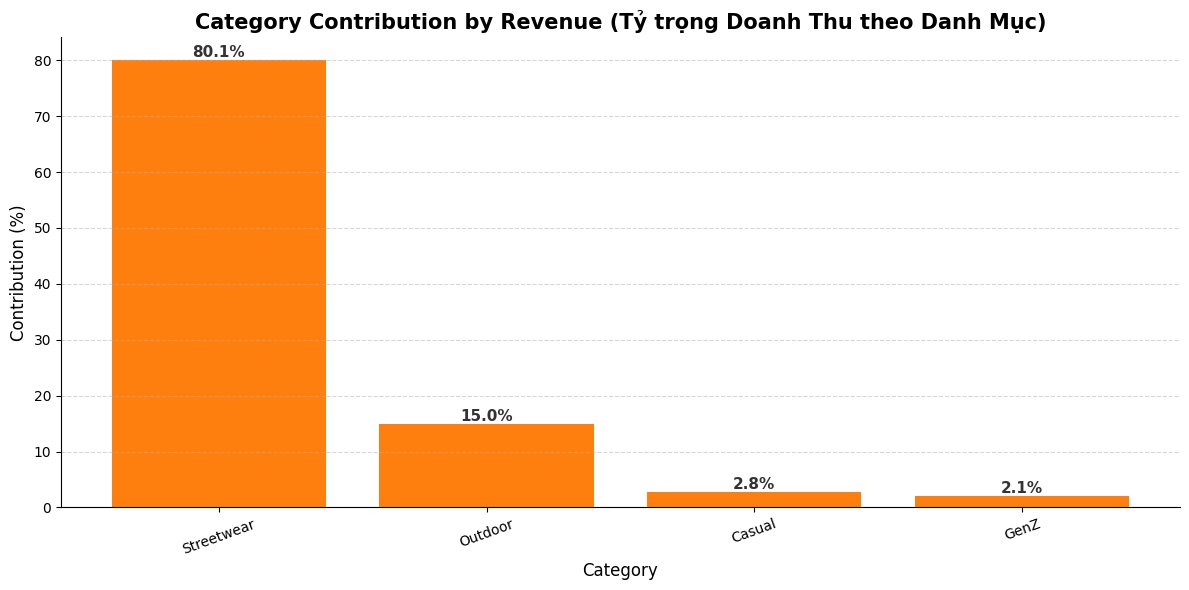

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
products = pd.read_csv(BASE_DATA + 'products.csv')
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')

# 2. Merge dữ liệu để lấy category cho từng item dựa vào product_id
order_items_merged = order_items.merge(products[['product_id', 'category']], on='product_id', how='inner')

# 3. Tính doanh thu (Revenue) cho mỗi sản phẩm bán ra
order_items_merged['revenue'] = (order_items_merged['quantity'] * order_items_merged['unit_price']) - order_items_merged['discount_amount'].fillna(0)

# 4. Gom nhóm tính tổng doanh thu theo Category 
category_revenue = order_items_merged.groupby('category')['revenue'].sum().sort_values(ascending=False)

# 5. Phân tích tỷ trọng phần trăm (Contribution)
total_revenue = category_revenue.sum()
category_percentage = (category_revenue / total_revenue) * 100

# ==========================================
# Vẽ biểu đồ Bar Chart Percentage
# ==========================================
plt.figure(figsize=(12, 6))
bars = plt.bar(category_percentage.index, category_percentage.values, color='#ff7f0e')

# Thêm số % lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#333333')

plt.title('Category Contribution by Revenue (Tỷ trọng Doanh Thu theo Danh Mục)', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Contribution (%)', fontsize=12)
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Bỏ viền thừa của biểu đồ cho thiết kế thanh thoát hơn
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


------------------------------
1. SỐ LƯỢNG ĐƠN TRẢ THỰC TẾ (SỐ LIỆU GỐC)
------------------------------
size           S     M     L    XL
category                          
Streetwear  5306  4828  4980  6620
Outdoor     3198  3966  4084  3434
GenZ         743   595   453   333
Casual       452   402   205   235

Tổng cộng tất cả đơn trả: 39834 đơn

------------------------------
2. TỔNG SỐ ĐƠN TRẢ THEO TỪNG CATEGORY
------------------------------
            Total_Orders
category                
Streetwear         21734
Outdoor            14682
GenZ                2124
Casual              1294

------------------------------
3. BẢNG TỶ TRỌNG PHẦN TRĂM (%) CỦA MỖI SIZE TRONG CATEGORY
------------------------------
size           S     M     L    XL
category                          
Streetwear 24.4% 22.2% 22.9% 30.5%
Outdoor    21.8% 27.0% 27.8% 23.4%
GenZ       35.0% 28.0% 21.3% 15.7%
Casual     34.9% 31.1% 15.8% 18.2%

Đang khởi tạo biểu đồ... Vui lòng đợi.


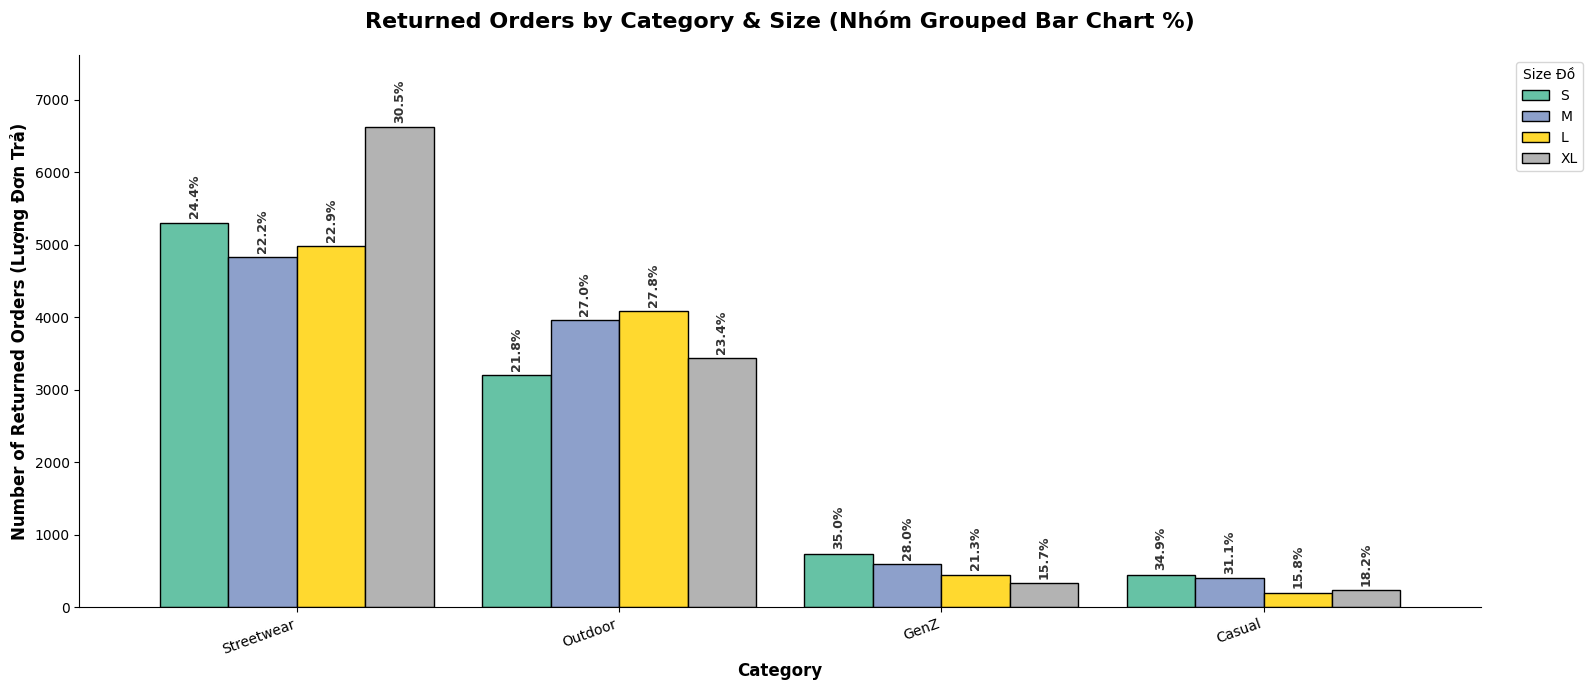

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
products = pd.read_csv(BASE_DATA + 'products.csv')
returns = pd.read_csv(BASE_DATA + 'returns.csv')

# 2. Merge dữ liệu
returns_merged = returns.merge(products[['product_id', 'category', 'size']], on='product_id', how='inner')
returns_merged['size'] = returns_merged['size'].astype(str).str.upper()

# 3. Tính "Số lượng Đơn hàng" bị trả theo Category & Size 
size_orders = returns_merged.groupby(['category', 'size'])['order_id'].nunique().unstack(fill_value=0)

# Sắp xếp size cho thuận mắt (Từ XS tới XXL)
standard_sizes = ['XS', 'S', 'M', 'L', 'XL', 'XXL']
valid_sizes = [s for s in standard_sizes if s in size_orders.columns]
other_sizes = [s for s in size_orders.columns if s not in valid_sizes]
size_orders = size_orders[valid_sizes + other_sizes]

# Tối ưu thiết kế: Sắp xếp các cột Trục X theo độ giảm dần
size_orders = size_orders.loc[size_orders.sum(axis=1).sort_values(ascending=False).index]

# 4. Tính trước Tổng các đơn của một Nhóm Category (để đo % tỷ trọng như yêu cầu)
category_totals = size_orders.sum(axis=1)

print("-" * 30)
print("1. SỐ LƯỢNG ĐƠN TRẢ THỰC TẾ (SỐ LIỆU GỐC)")
print("-" * 30)
# In bảng size_orders (Số lượng tuyệt đối)
print(size_orders)
print(f"\nTổng cộng tất cả đơn trả: {category_totals.sum()} đơn")

print("\n" + "-" * 30)
print("2. TỔNG SỐ ĐƠN TRẢ THEO TỪNG CATEGORY")
print("-" * 30)
print(category_totals.to_frame(name='Total_Orders'))

print("\n" + "-" * 30)
print("3. BẢNG TỶ TRỌNG PHẦN TRĂM (%) CỦA MỖI SIZE TRONG CATEGORY")
print("-" * 30)
# Tính toán bảng % bằng cách chia size_orders cho tổng hàng ngang (axis=0)
size_pct = size_orders.div(category_totals, axis=0) * 100

# Định dạng in ấn: làm tròn 1 chữ số thập phân cho dễ nhìn
pd.options.display.float_format = '{:.1f}%'.format
print(size_pct)

# Trả lại định dạng mặc định cho pandas nếu cần dùng tiếp phía sau
pd.reset_option('display.float_format')

print("\n" + "=" * 50)
print("Đang khởi tạo biểu đồ... Vui lòng đợi.")
print("=" * 50)

# ==============================================================
# Vẽ biểu đồ GROUPED Bar Chart (Các cột size đứng thành cụm)
# ==============================================================
# ĐỔI stacked=False để dàn hàng ngang
ax = size_orders.plot(kind='bar', stacked=False, figsize=(16, 7), colormap='Set2', edgecolor='black', width=0.85)

# Vòng lặp đính nhãn % lên "Đỉnh" của cột
for c in ax.containers:
    labels = []
    for j, val in enumerate(c.datavalues):
        total_for_this_category = category_totals.iloc[j]
        # Chuyển đổi trị số đơn hàng -> Số phần trăm
        if val > 0 and total_for_this_category > 0:
            pct = (val / total_for_this_category) * 100
            # Ngưỡng > 2% mới hiện nhãn
            if pct > 2.0: 
                labels.append(f'{pct:.1f}%')
            else:
                labels.append('')
        else:
            labels.append('')
            
    # TRỌNG TÂM: Để label ở đỉnh (edge), thêm padding đẩy nhãn cao lên, và quay dựng đứng (rotation=90)
    ax.bar_label(c, labels=labels, label_type='edge', padding=3, fontsize=9, fontweight='bold', color='#333333', rotation=90)

plt.title('Returned Orders by Category & Size (Nhóm Grouped Bar Chart %)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Number of Returned Orders (Lượng Đơn Trả)', fontsize=12, fontweight='bold')

plt.xticks(rotation=20, ha='right')

# Trick tạo thêm tí không gian vòm cho biểu đồ phía trên nóc (margins) để chữ không lấn lề
plt.margins(y=0.15)

# Tối ưu legend 
plt.legend(title='Size Đồ', bbox_to_anchor=(1.02, 1), loc='upper left')

# Bỏ viền nẹp
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


--------------------------------------------------
PHÂN TÍCH DỮ LIỆU TRẢ HÀNG THEO PHÂN KHÚC LAI TẠO
--------------------------------------------------

[1] SỐ LƯỢNG ĐƠN TRẢ (GIÁ TRỊ TUYỆT ĐỐI):
size                     S     M     L    XL
split_segment                               
Activewear - Outdoor  2658  3465  3896  2953
Everyday              2913  2878  1890  2452
Balanced              1021   936  1541  2110
Performance           1124   920  1417  1974
Trendy                 743   595   453   333
Premium                547   505   188   481
All-weather            429   381   183   214
Standard               255   107   137   102
Activewear - Casual     23    21    22    21

[2] TỔNG ĐƠN TRẢ THEO NHÓM (Dùng làm mẫu số tính %):
                      Total_Orders %_of_Grand_Total
split_segment                                      
Activewear - Outdoor         12972            32.5%
Everyday                     10133            25.4%
Balanced                      5608            14

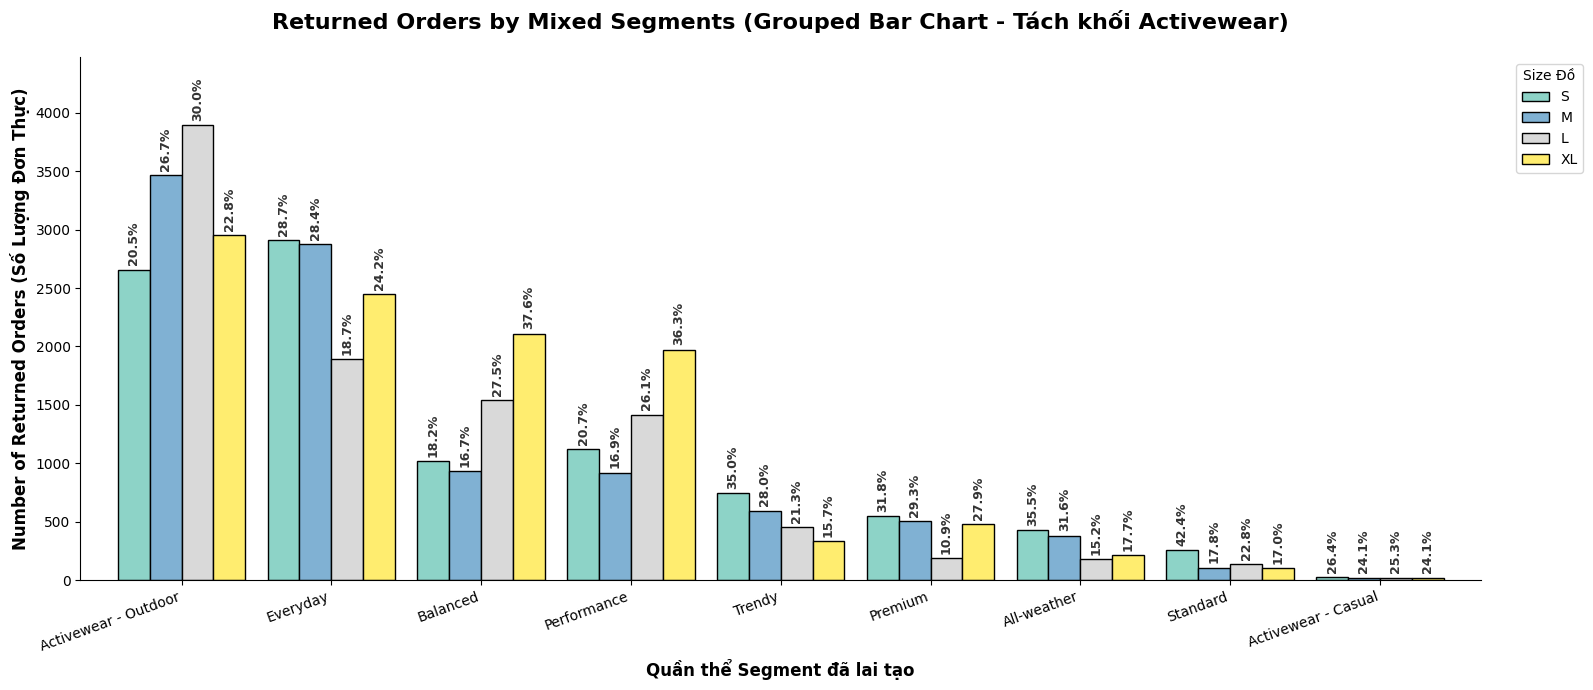

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu
BASE_DATA = "data/"
products = pd.read_csv(BASE_DATA + 'products.csv')
returns = pd.read_csv(BASE_DATA + 'returns.csv')

# LÕI CẬP NHẬT: Tạo ra 1 phân khúc "Lai Tạo Xẻ Đôi" (split_segment)
products['split_segment'] = products.apply(
    lambda x: f"Activewear - {x['category']}" if x['segment'] == 'Activewear' else x['segment'], 
    axis=1
)

# 2. Merge dữ liệu để lấy Cục phân nhóm lai tạo này và Size
returns_merged = returns.merge(products[['product_id', 'split_segment', 'size']], on='product_id', how='inner')
returns_merged['size'] = returns_merged['size'].astype(str).str.upper()

# 3. Tính "Số lượng Đơn hàng" bị trả theo Split_Segment & Size 
size_orders = returns_merged.groupby(['split_segment', 'size'])['order_id'].nunique().unstack(fill_value=0)

# Sắp xếp size cho thuận mắt (Từ XS tới XXL)
standard_sizes = ['XS', 'S', 'M', 'L', 'XL', 'XXL']
valid_sizes = [s for s in standard_sizes if s in size_orders.columns]
other_sizes = [s for s in size_orders.columns if s not in valid_sizes]
size_orders = size_orders[valid_sizes + other_sizes]

# Tối ưu giao diện: Sắp xếp các cột Trục X theo độ giảm dần Lượng Trả Hàng
size_orders = size_orders.loc[size_orders.sum(axis=1).sort_values(ascending=False).index]

# 4. Tính trước Tổng các đơn của một Nhóm (để quy đổi ra % dán lên khu vực nóc thanh)
split_totals = size_orders.sum(axis=1)

print("-" * 50)
print("PHÂN TÍCH DỮ LIỆU TRẢ HÀNG THEO PHÂN KHÚC LAI TẠO")
print("-" * 50)

# 1. Bảng số lượng đơn hàng thực tế
print("\n[1] SỐ LƯỢNG ĐƠN TRẢ (GIÁ TRỊ TUYỆT ĐỐI):")
print(size_orders)

# 2. Tổng số đơn theo từng Segment lai tạo
print("\n[2] TỔNG ĐƠN TRẢ THEO NHÓM (Dùng làm mẫu số tính %):")
summary_df = split_totals.to_frame(name='Total_Orders')
# Tính thêm % đóng góp của mỗi nhóm vào tổng lượng trả hàng toàn công ty
summary_df['%_of_Grand_Total'] = (summary_df['Total_Orders'] / split_totals.sum()) * 100
print(summary_df.map(lambda x: f"{x:.1f}%" if isinstance(x, float) else x))

# 3. Bảng tỷ trọng % của từng Size trong mỗi Nhóm
print("\n[3] BẢNG TỶ TRỌNG % CỦA SIZE TRONG MỖI NHÓM:")
# Tính toán ma trận %
size_pct = size_orders.div(split_totals, axis=0) * 100

# Thiết lập định dạng in ấn chuyên nghiệp cho Pandas
pd.options.display.float_format = '{:.1f}%'.format
print(size_pct)

# Reset định dạng để không ảnh hưởng đến các xử lý số học phía sau (nếu có)
pd.reset_option('display.float_format')
# ==============================================================
# Vẽ biểu đồ GROUPED Bar Chart lai tạo (Các size tách rời đứng cạnh nhau)
# ==============================================================
# ĐỔI BẬT: stacked=False thay vì True
ax = size_orders.plot(kind='bar', stacked=False, figsize=(16, 7), colormap='Set3', edgecolor='black', width=0.85)

# Vòng lặp đính nhãn % lên "Đỉnh cạnh (edge)" từng thanh
for c in ax.containers:
    labels = []
    for j, val in enumerate(c.datavalues):
        total_for_this_group = split_totals.iloc[j]
        # Chuyển đổi con số tuyệt đối thành "%"
        if val > 0 and total_for_this_group > 0:
            pct = (val / total_for_this_group) * 100
            # Giữ mức độ sạch sẽ: Mở rộng bộ gen, in cả những số > 2.0%
            if pct > 2.0: 
                labels.append(f'{pct:.1f}%')
            else:
                labels.append('')
        else:
            labels.append('')
            
    # TRỌNG TÂM DỊCH CHUYỂN: label_type='edge', đẩy cong ngược lên trời rotation=90
    ax.bar_label(c, labels=labels, label_type='edge', padding=3, fontsize=9, fontweight='bold', color='#333333', rotation=90)


plt.title('Returned Orders by Mixed Segments (Grouped Bar Chart - Tách khối Activewear)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Quần thể Segment đã lai tạo', fontsize=12, fontweight='bold')
plt.ylabel('Number of Returned Orders (Số Lượng Đơn Thực)', fontsize=12, fontweight='bold')

# Góc nghiêng 20 độ vớt vát độ dài của tên xẻ rãnh Activewear
plt.xticks(rotation=20, ha='right')

# Tăng không gian không khí vòm trần (margin) lên để mảng chữ 90 độ khỏi bị gãy đầu
plt.margins(y=0.15)

# Tối ưu legend ra góc phải trên
plt.legend(title='Size Đồ', bbox_to_anchor=(1.02, 1), loc='upper left')

# Bỏ viền thừa phảng phất vẻ chuyên nghiệp
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


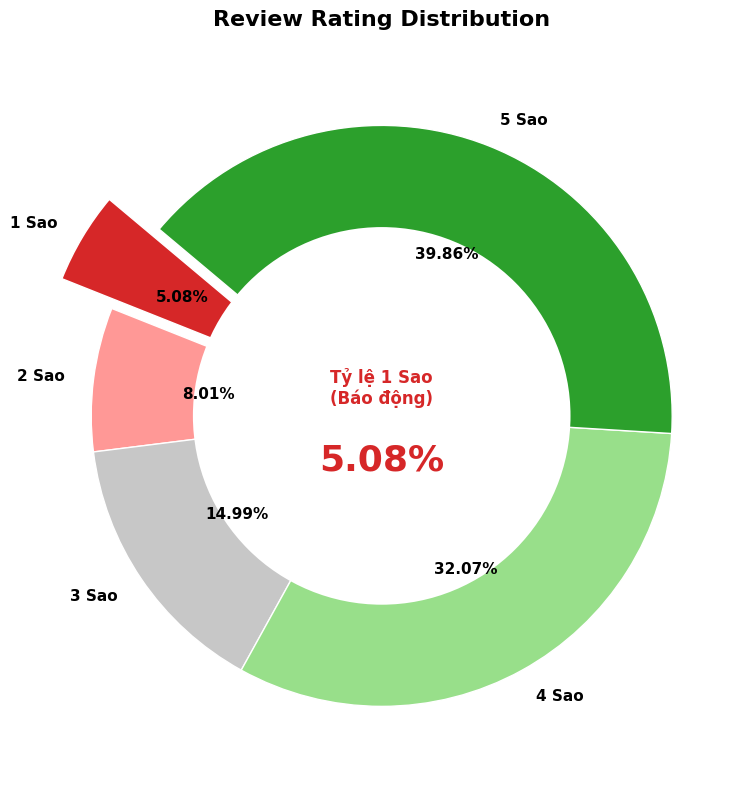

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu đánh giá
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv')

# 2. Đếm số lượng theo giá trị rating (từ 1 đến 5 sao)
rating_counts = reviews['rating'].value_counts()
total_reviews = len(reviews)

# Chuẩn hóa thứ tự index từ 1 đến 5 sao (với mapping string)
mapping = {1: '1 Sao', 2: '2 Sao', 3: '3 Sao', 4: '4 Sao', 5: '5 Sao'}
rating_counts.index = rating_counts.index.map(mapping)
rating_counts = rating_counts.reindex(['1 Sao', '2 Sao', '3 Sao', '4 Sao', '5 Sao']).fillna(0)

# 3. Tính % tỷ lệ phân bổ của các sao
percentage = rating_counts / total_reviews

# ==========================================
# Vẽ biểu đồ Donut Chart (Highlight 1 Sao bị vỡ ra khỏi bánh)
# ==========================================
# Set màu: Trắng/đỏ để nhấn mạnh sự tiêu cực của 1 sao, các review cao dần thì xanh lá
colors = ['#d62728', '#ff9896', '#c7c7c7', '#98df8a', '#2ca02c'] 
explode = (0.2, 0, 0, 0, 0)  # Tách lát cắt 1 sao (index 0) ra khỏi bánh

plt.figure(figsize=(8, 8))
plt.pie(percentage, explode=explode, labels=percentage.index, colors=colors, 
        autopct='%1.2f%%', startangle=140, textprops={'fontsize': 11, 'weight': 'bold'},
        wedgeprops=dict(edgecolor='w'))

# Thêm vòng tròn trắng ở giữa để tạo thành Donut chart đương đại
centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# In số liệu đúc kết của phần 1 Sao ngay ở giữa tâm chart!
one_star_pct = percentage.get('1 Sao', 0)
plt.text(0, 0.1, 'Tỷ lệ 1 Sao\n(Báo động)', ha='center', va='center', fontsize=12, color='#d62728', fontweight='bold')
plt.text(0, -0.15, f'{one_star_pct:.2%}', ha='center', va='center', fontsize=26, color='#d62728', fontweight='bold')

plt.title('Review Rating Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# 2. Sentiment Analysis

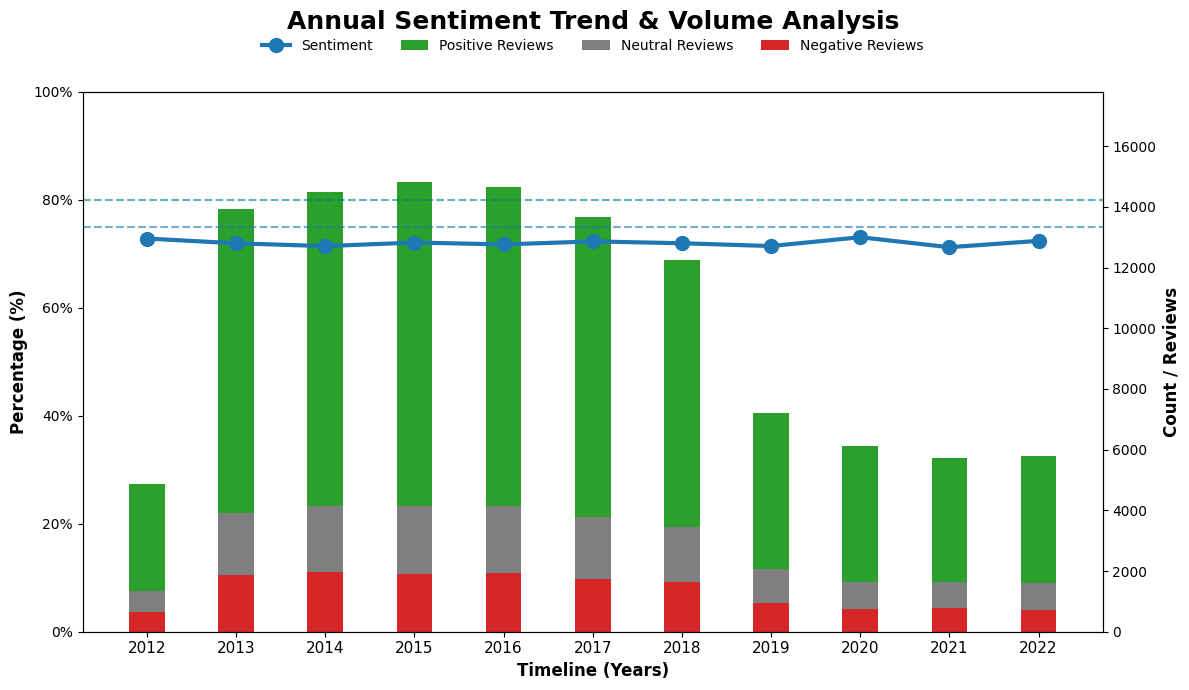

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# 1. Đọc dữ liệu (Bỏ lọc năm 2022 để lấy toàn bộ các năm có trong data)
BASE_DATA = "data/"
reviews = pd.read_csv(BASE_DATA + 'reviews.csv', parse_dates=['review_date'])

# 2. Phân loại Cảm xúc (Sentiment Rating)
def classify_rating(r):
    if r in [1, 2]: return 'Negative'
    elif r == 3: return 'Neutral'
    else: return 'Positive'

reviews['sentiment'] = reviews['rating'].apply(classify_rating)

reviews['Year'] = reviews['review_date'].dt.year

# 3. Gom nhóm theo Năm
pivot = reviews.groupby(['Year', 'sentiment']).size().unstack(fill_value=0)

# Đảm bảo có đủ 3 cột
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in pivot.columns:
        pivot[col] = 0

pivot['Total'] = pivot['Negative'] + pivot['Neutral'] + pivot['Positive']
pivot['Sentiment_Pct'] = (pivot['Positive'] / pivot['Total']) * 100

# Chuẩn bị dữ liệu vẽ
x_labels = pivot.index.astype(str).tolist()
pos = pivot['Positive'].values
neu = pivot['Neutral'].values
neg = pivot['Negative'].values
sentiment_line = pivot['Sentiment_Pct'].values

# ==========================================
# VẼ BIỂU ĐỒ KÉP (DUAL AXIS CHART)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 7))

# Trục phụ ax2 (Cột chồng - Secondary Right Y-Axis)
ax2 = ax1.twinx()
width = 0.4 # Giảm độ rộng cột vì số lượng năm thường ít hơn số tháng
x_pos = np.arange(len(x_labels))

# Vẽ cột chồng
p_neg = ax2.bar(x_pos, neg, width, label='Negative Reviews', color='#d62728', zorder=2)
p_neu = ax2.bar(x_pos, neu, width, bottom=neg, label='Neutral Reviews', color='#7f7f7f', zorder=2)
p_pos = ax2.bar(x_pos, pos, width, bottom=neg+neu, label='Positive Reviews', color='#2ca02c', zorder=2)

ax2.set_ylabel('Count / Reviews', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(pivot['Total']) * 1.2) 

# Trục chính ax1 (Line - Primary Left Y-Axis)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

p_line, = ax1.plot(x_pos, sentiment_line, color='#1f77b4', marker='o', markersize=10, 
                   linewidth=3, label='Sentiment', zorder=3)

ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(PercentFormatter())

# Đường Tham Chiếu
ax1.axhline(75, color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
ax1.axhline(80, color='#008080', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

# Format Trục hoành theo Năm
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, fontsize=11)
ax1.set_xlabel('Timeline (Years)', fontsize=12, fontweight='bold')

# Legend & Summary
handles = [p_line, p_pos, p_neu, p_neg]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)

plt.title('Annual Sentiment Trend & Volume Analysis', pad=45, fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
display(pivot)

sentiment,Negative,Neutral,Positive,Total,Sentiment_Pct
Year,,,,,
2012,650,678,3551,4879,72.781308
2013,1859,2059,10024,13942,71.897863
2014,1974,2174,10347,14495,71.383236
2015,1901,2246,10687,14834,72.043953
2016,1928,2220,10505,14653,71.691804
2017,1736,2060,9883,13679,72.249433
2018,1629,1809,8801,12239,71.909470
2019,948,1109,5134,7191,71.394799
2020,741,906,4459,6106,73.026531


/var/folders/yf/z8cyz0qn4r557bdjflrksgkw0000gn/T/ipykernel_50553/1269298129.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(BASE_DATA + 'order_items.csv')


Đã xuất chiến lược cho nhóm Stars (Mũi nhọn - Đẩy mạnh) vào file strategy_stars.txt
Đã xuất chiến lược cho nhóm Hidden Gems (Tiềm ẩn - Cần Marketing) vào file strategy_hidden_gems.txt
Đã xuất chiến lược cho nhóm Cash Cows (Vắt sữa cơ bản) vào file strategy_cash_cows.txt
Đã xuất chiến lược cho nhóm Dogs (Kém hiệu quả - Hạn chế R&D) vào file strategy_dogs.txt


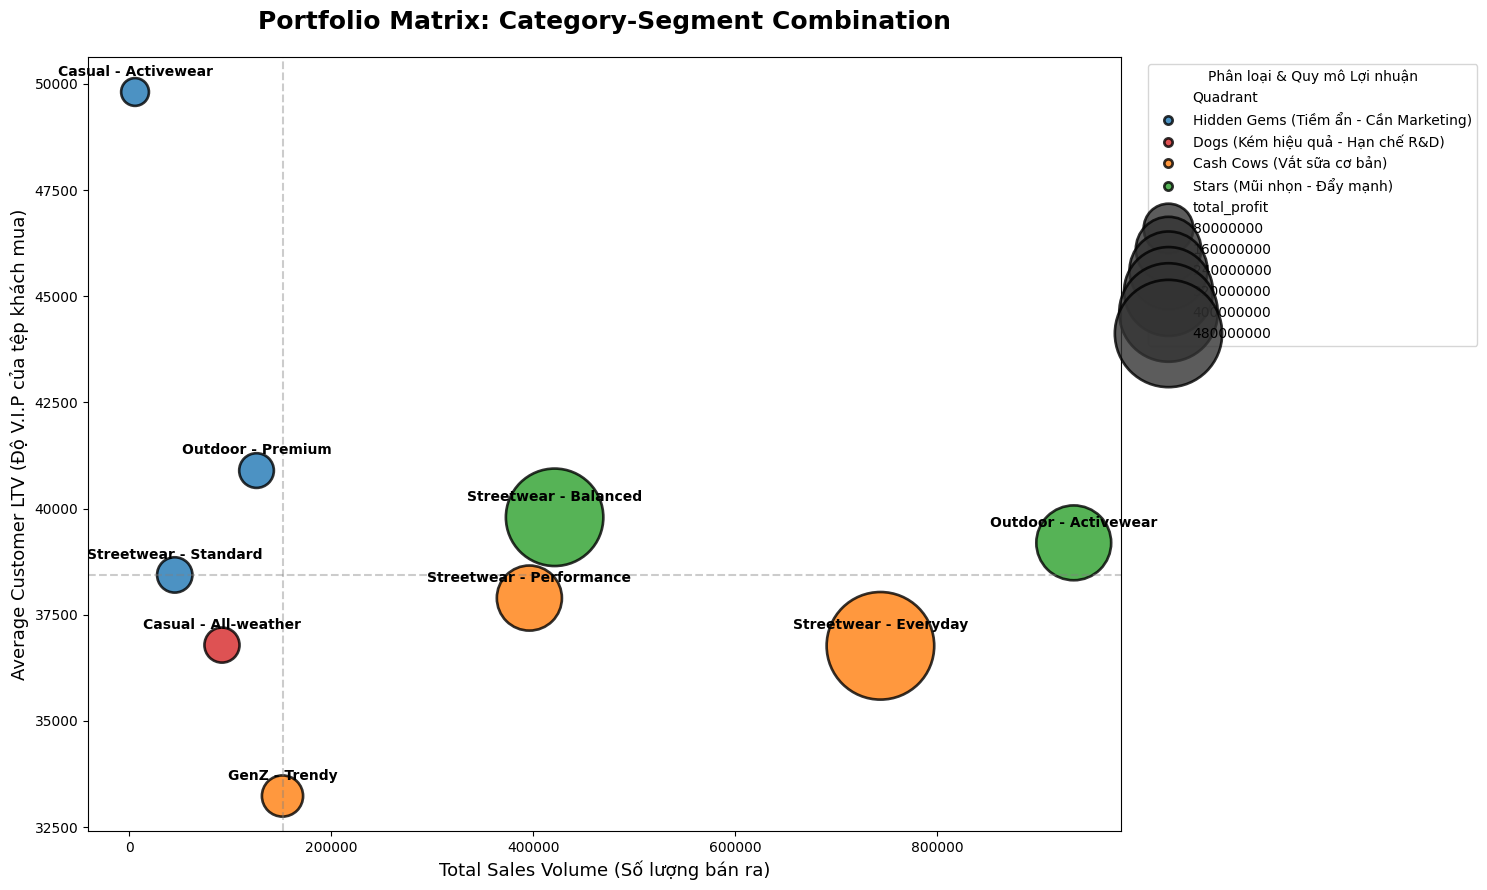

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Đọc dữ liệu
BASE_DATA = "data/"
orders = pd.read_csv(BASE_DATA + 'orders.csv')
order_items = pd.read_csv(BASE_DATA + 'order_items.csv')
products = pd.read_csv(BASE_DATA + 'products.csv')

# Lọc đơn vị hủy
orders = orders[orders['order_status'] != 'cancelled']

# 2. Merge các bảng
df = order_items.merge(orders[['order_id', 'customer_id']], on='order_id', how='inner')
df = df.merge(products[['product_id', 'category', 'segment', 'cogs']], on='product_id', how='inner')

# 3. Tính Profit & Customer LTV
df['profit'] = (df['quantity'] * df['unit_price']) - df['discount_amount'].fillna(0) - (df['quantity'] * df['cogs'])
customer_ltv = df.groupby('customer_id')['profit'].sum().reset_index()
customer_ltv.rename(columns={'profit': 'customer_LTV'}, inplace=True)
df = df.merge(customer_ltv, on='customer_id', how='left')

# ==============================================================
# 4. PHÂN TÍCH TỔ HỢP "CATEGORY - SEGMENT"
# ==============================================================
# Tạo cột định danh tổ hợp
df['cat_seg'] = df['category'] + " - " + df['segment']

cat_seg_stats = df.groupby(['category', 'segment', 'cat_seg']).agg(
    total_sales_volume=('quantity', 'sum'),
    avg_buyer_LTV=('customer_LTV', 'mean'),
    total_profit=('profit', 'sum')
).reset_index()

# 5. Phân bổ Quadrant dựa theo Median của các tổ hợp
med_volume = cat_seg_stats['total_sales_volume'].median()
med_ltv = cat_seg_stats['avg_buyer_LTV'].median()

# Hằng số mô tả (Giữ nguyên logic của bạn)
STARS = 'Stars (Mũi nhọn - Đẩy mạnh)'
GEMS  = 'Hidden Gems (Tiềm ẩn - Cần Marketing)'
COWS  = 'Cash Cows (Vắt sữa cơ bản)'
DOGS  = 'Dogs (Kém hiệu quả - Hạn chế R&D)'

def classify_cat_seg(row):
    if row['total_sales_volume'] >= med_volume and row['avg_buyer_LTV'] >= med_ltv:
        return STARS
    elif row['total_sales_volume'] < med_volume and row['avg_buyer_LTV'] >= med_ltv:
        return GEMS
    elif row['total_sales_volume'] >= med_volume and row['avg_buyer_LTV'] < med_ltv:
        return COWS
    else:
        return DOGS

cat_seg_stats['Quadrant'] = cat_seg_stats.apply(classify_cat_seg, axis=1)

# ==============================================================
# 6. XUẤT RA 4 FILE CHIẾN LƯỢC
# ==============================================================
file_mapping = {
    STARS: "strategy_stars.txt",
    GEMS:  "strategy_hidden_gems.txt",
    COWS:  "strategy_cash_cows.txt",
    DOGS:  "strategy_dogs.txt"
}

for label, file_name in file_mapping.items():
    subset = cat_seg_stats[cat_seg_stats['Quadrant'] == label].sort_values(by='total_profit', ascending=False)
    with open(file_name, 'w', encoding='utf-8') as f:
        f.write(f"--- ĐỊNH HƯỚNG: {label.upper()} ---\n\n")
        f.write(f"{'CATEGORY-SEGMENT':<35} | {'AVG LTV':<12} | {'VOLUME':<10} | {'PROFIT':<10}\n")
        f.write("-" * 80 + "\n")
        for _, row in subset.iterrows():
            f.write(f"{row['cat_seg']:<35} | ${row['avg_buyer_LTV']:<11,.0f} | {row['total_sales_volume']:<10,} | ${row['total_profit']:,.0f}\n")
    print(f"Đã xuất chiến lược cho nhóm {label} vào file {file_name}")

# ==========================================
# 7. TRỰC QUAN HÓA (BUBBLE PLOT)
# ==========================================
plt.figure(figsize=(15, 9))
palette_dict = {STARS: '#2ca02c', GEMS: '#1f77b4', COWS: '#ff7f0e', DOGS: '#d62728'}

sns.scatterplot(
    data=cat_seg_stats, 
    x='total_sales_volume', y='avg_buyer_LTV', 
    hue='Quadrant', palette=palette_dict,
    size='total_profit', sizes=(400, 6000), alpha=0.8, edgecolor='black'
)

# Đường tham chiếu
plt.axvline(med_volume, color='gray', linestyle='--', alpha=0.4)
plt.axhline(med_ltv, color='gray', linestyle='--', alpha=0.4)

# Dán nhãn trực tiếp lên bong bóng
for _, row in cat_seg_stats.iterrows():
    plt.text(row['total_sales_volume'], row['avg_buyer_LTV'] + (med_ltv*0.01), 
             row['cat_seg'], fontsize=10, ha='center', weight='semibold')

plt.title('Portfolio Matrix: Category-Segment Combination', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Sales Volume (Số lượng bán ra)', fontsize=13)
plt.ylabel('Average Customer LTV (Độ V.I.P của tệp khách mua)', fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Phân loại & Quy mô Lợi nhuận")
plt.tight_layout()
plt.show()